In [1]:
script = False
cluster = False

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from efficientnet_pytorch import EfficientNet

from astropy.io import fits
from astropy.table import Table
from astropy.visualization import make_lupton_rgb

if(script):
    from tqdm import tqdm
else: 
    from tqdm.notebook import tqdm

plt.style.use('dark_background')

## ML Components 

In [2]:
num_workers = 0

transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))])

In [3]:
class ImageDataset(Dataset):
    """Dataset of Images, Data and Labels"""

    def __init__(self, images, data, labels, transform=None):
        """
        Create a PyTorch dataset from an array of images
		and an array of labels
        """
        super().__init__()
        self.images = images
        self.data = data
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.images[idx]
        
        new_image = np.empty((3, NUM_PIX, NUM_PIX))
        new_image[0], new_image[1], new_image[2] =  self.normalize_image(image)
        new_image = new_image.transpose(1,2,0)
        new_image = Image.fromarray(np.uint8(255*new_image)).convert("RGB")
        label = self.labels[idx]
        
        data_point = self.data.iloc[idx].to_dict()
        sample = {'image': self.transform(new_image), 'label': label, 'img': image, 'data': data_point}
        return sample
    
    def normalize_image(self, image):
        image_g = (image[0]-np.mean(image[0]))/ np.std(image[0])
        image_r = (image[1]-np.mean(image[1]))/ np.std(image[1])
        image_i = (image[2]-np.mean(image[2]))/ np.std(image[2])

        image_g = (image_g-np.min(image_g))/ (np.max(image_g) - np.min(image_g))
        image_r = (image_r-np.min(image_r))/ (np.max(image_r) - np.min(image_r))
        image_i = (image_i-np.min(image_i))/ (np.max(image_i) - np.min(image_i))
        return(image_i, image_r, image_g)

In [4]:
class EfficientNetClass(nn.Module):
    
    def __init__(self, n_classes, pretrained=False):
        super(EfficientNetClass, self).__init__()
        if(not cluster):
            self.model = EfficientNet.from_pretrained('efficientnet-b0',  num_classes=n_classes)
            torch.save(self.model.state_dict(), 'initial_model.pt')
        else:
            self.model = EfficientNet.from_name('efficientnet-b0',  num_classes=n_classes)
            self.model.load_state_dict(torch.load('initial_model.pt'))
            
    def forward(self, x):
        x = self.model(x)
        return x

In [5]:
model = EfficientNetClass(n_classes=14, pretrained=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

name = 'Exp/exp2/model_tmp.pt'#'model.pt'#'other.pt' 
model = torch.load(name, map_location=torch.device('cpu'))

Loaded pretrained weights for efficientnet-b0


## Simulations data

In [6]:
# Crop images, so they have the same angular size as my DES images
# Euclid pixel scale: 0.1 arcsec/pixel. DES image angular size: 11.8665 arcsec. 11.8665/0.1 ~ 119 pixels
def center_crop(images, crop_size=119):
    _, _, h, w = images.shape
    start_h = (h - crop_size) // 2
    start_w = (w - crop_size) // 2
    return images[:, :, start_h:start_h + crop_size, start_w:start_w + crop_size]

#e1, e2 from q and phi
def q_phi_to_ellipticity(q, phi):
    """
    Convert axis ratio q and position angle phi to ellipticity components e1, e2.
    
    Parameters:
        q:   axis ratio (b/a), between 0 and 1
        phi: position angle in radians
    """
    e = (1 - q) / (1 + q)
    e1 = e * np.cos(2 * phi)
    e2 = e * np.sin(2 * phi)
    return e1, e2

In [7]:
NUM_PIX = 119

#Images
path = '/Users/jimenagonzalez/research/DSPL/Hybrid_SL_Modeling/data/candidates_tocompare/Euclid_Simulations/train/measurements_sersic-sie_sigma_noise=1.0e-02/'
files = os.listdir(path)

images = []
for file in files:
    filepath = path + file
    arr = np.load(filepath)
    image = np.array((arr, arr, arr))
    images.append(image)
images = np.array(images)
images = center_crop(images)


#Saving all data into one dataframe
path = '/Users/jimenagonzalez/research/DSPL/Hybrid_SL_Modeling/data/candidates_tocompare/Euclid_Simulations/train/'
path_mass = 'lens_mass_sersic-sie_sigma_noise=1.0e-02/'
path_lens_light = 'lens_light_sersic-sie_sigma_noise=1.0e-02/'
path_source_light = 'source_light_sersic-sie_sigma_noise=1.0e-02/'

frames1, frames2, frames3 = [], [], []
files = os.listdir(path + path_mass)
for i in range(len(files)):
    filename1 = path + path_mass + 'lens_mass_' + str(i) + '.npy'
    arr = np.load(filename1)
    frames1.append(arr)
    
    filename2 = path + path_lens_light  + 'lens_light_' + str(i) + '.npy'
    arr = np.load(filename2)
    frames2.append(arr)
    
    filename3 = path + path_source_light   + 'source_light_' + str(i) + '.npy'
    arr = np.load(filename3)
    frames3.append(arr)

column_names1 = ['center_x_lens', 'center_y_lens', 'q_lens_mass', 'phi_lens_mass', 'EINSTEIN_RADIUS']
column_names2 = ['x_lens_light', 'y_lens_light', 'q_lens_light', 'phi_lens_light', 'n_sersic_lens_light', 
                 'R_sersic_lens_light', 'Io_lens']
column_names3 = ['center_x_source', 'center_y_source', 'q_source', 'phi_source', 'n_sersic_source_light', 
                 'R_sersic_source_light', 'Ie_source']

data_mass = pd.DataFrame(frames1, columns=column_names1)
data_lens_light = pd.DataFrame(frames2, columns = column_names2)
data_source_light = pd.DataFrame(frames3, columns = column_names3)

e1, e2 = q_phi_to_ellipticity(data_mass['q_lens_mass'], data_mass['phi_lens_mass'])
data_mass['e1_lens'] = e1
data_mass['e2_lens'] = e2

e1, e2 = q_phi_to_ellipticity(data_lens_light['q_lens_light'], data_lens_light['phi_lens_light'])
data_mass['e1_lens_light'] = e1
data_mass['e2_lens_light'] = e2

e1, e2 = q_phi_to_ellipticity(data_source_light['q_source'], data_source_light['phi_source'])
data_source_light['e1_source_light'] = e1
data_source_light['e2_source_light'] = e2

labels_dataset = torch.tensor(data_mass.values, dtype=torch.float32)
data_combined = pd.concat([data_mass, data_lens_light, data_source_light], axis=1)
data = data_combined
data.head()

,center_x_lens,center_y_lens,q_lens_mass,phi_lens_mass,EINSTEIN_RADIUS,e1_lens,e2_lens,e1_lens_light,e2_lens_light,x_lens_light,...,Io_lens,center_x_source,center_y_source,q_source,phi_source,n_sersic_source_light,R_sersic_source_light,Ie_source,e1_source_light,e2_source_light
0,-0.006847,0.009930,0.551638,2.397776,0.704655,0.024003,-0.287962,-0.053677,-0.034059,-0.022524,...,0.0,0.0,0.0,0.258038,0.280119,1.635500,1.010574,23.344425,0.499617,0.313400
1,0.020739,-0.002881,0.833528,1.439647,1.457819,-0.087688,0.023543,-0.028251,-0.089001,-0.186637,...,0.0,0.0,0.0,0.305476,0.836462,1.654799,0.426350,4.016958,-0.054239,0.529237
2,-0.009766,-0.008206,0.661249,2.553269,1.129881,0.078307,-0.188278,0.155197,-0.126876,-0.012314,...,0.0,0.0,0.0,0.500684,2.817559,1.531407,1.181426,42.595558,0.265266,-0.200849
3,-0.015818,0.015822,0.809459,1.189132,1.140218,-0.076085,0.072799,0.181199,-0.013674,-0.035596,...,0.0,0.0,0.0,0.467170,1.096133,1.535022,1.017125,29.133221,-0.211448,0.295265
4,-0.016201,0.017466,0.746559,1.045691,0.999022,-0.072176,0.125886,0.004037,0.011039,-0.053920,...,0.0,0.0,0.0,0.350357,0.584263,1.437104,0.964941,13.623817,0.188351,0.442687


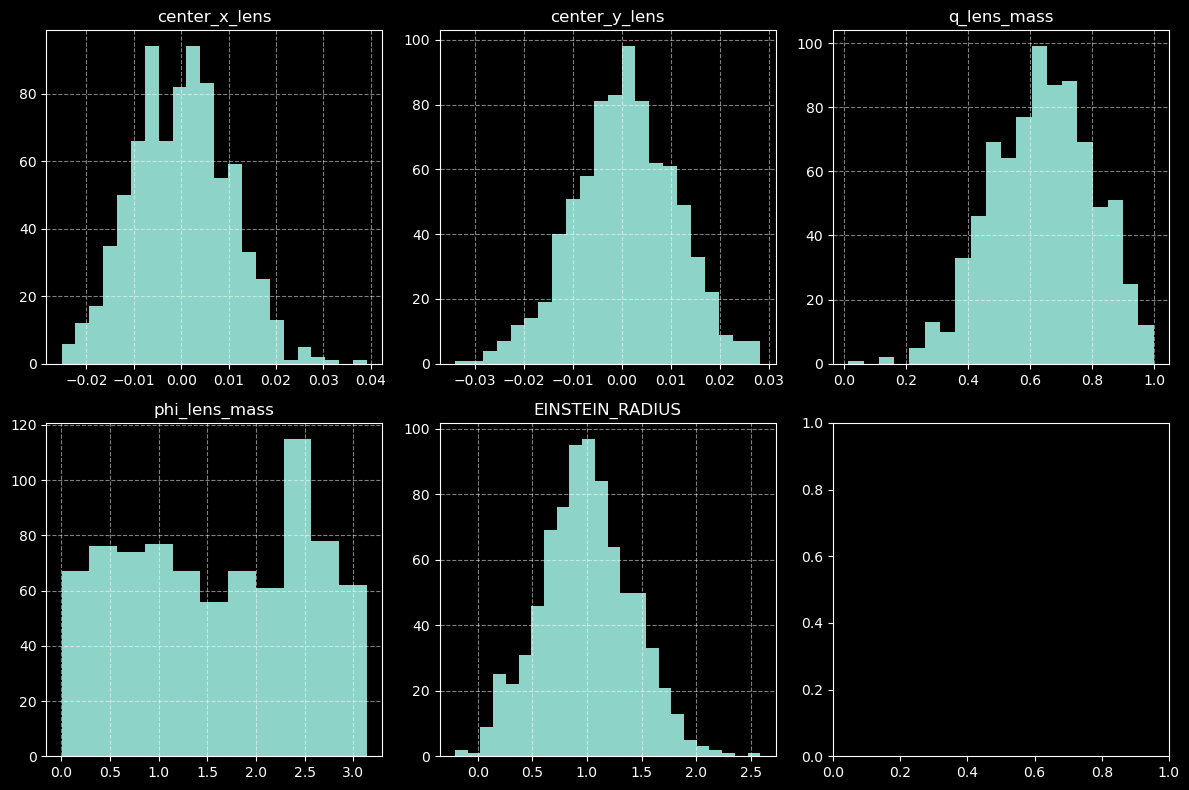

In [8]:
modeling_param = ['center_x_lens', 'center_y_lens', 'q_lens_mass', 'phi_lens_mass', 'EINSTEIN_RADIUS']

# Max likelihood for each parameter
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for ax, (label) in zip(axes, modeling_param):
    ax.hist(data[label], bins='auto')
    ax.set_title(label)
    ax.grid(which='both',  linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
plt.close()

In [9]:
print(images.shape, len(labels_dataset))
dataset = ImageDataset(images, data, labels_dataset, transform=transform)
data_loader = torch.utils.data.DataLoader(dataset=dataset, batch_size=1, num_workers=num_workers, shuffle=True)

(800, 3, 119, 119) 800


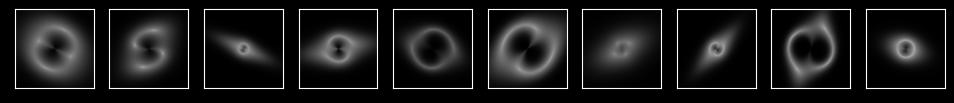

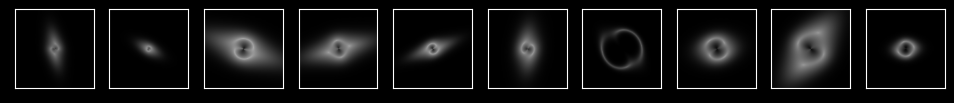

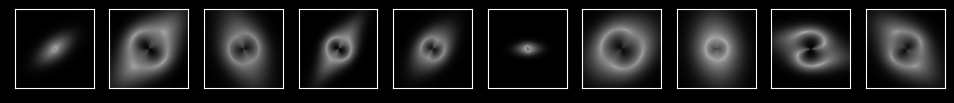

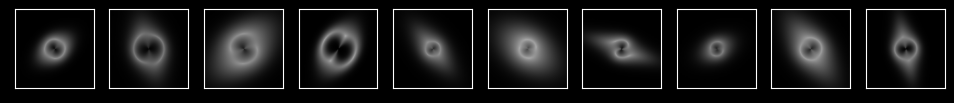

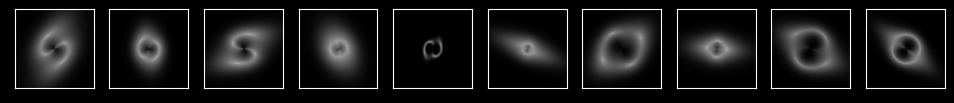

In [10]:
def make_plot_all(objects, title, data, Q, stretch, minimum):
    for i in range(len(objects)):
        if(i%10 == 0):
            plt.figure(figsize=(12,2))
            for j in range(10):
                if(i+j > len(objects)-1): break
                plt.subplot(1,10,j+1)
                rgb = make_lupton_rgb(objects[i+j][0], objects[i+j][1], objects[i+j][2], 
                                    Q=Q, stretch=stretch, minimum=minimum)
                plt.imshow(rgb, aspect='equal')
                plt.xticks([], [])
                plt.yticks([], []) 
            #plt.savefig(png_filepath + title + '.png', bbox_inches='tight')
            plt.show() 

N_test = 50
images_tmp = images[0:N_test]
data_tmp = data.iloc[0:N_test]
make_plot_all(images_tmp, 'title', data_tmp, 9, 40, (0, 0, 0))

## Evaluating Performance

In [11]:
def testing_analysis(test_loader):
    predicted_data, true_data = pd.DataFrame(), pd.DataFrame()
    for i, sample in enumerate(tqdm(test_loader)):
        #if(i == 50): break 
        data, target, sample_img, sample_data = sample['image'], sample['label'] , sample['img'], sample['data']

        output = model.forward(data)
        output = pd.DataFrame(output.detach().cpu().numpy())
        
        predicted_data = predicted_data.append(output)
        true_data = true_data.append(pd.DataFrame(target.cpu().numpy()))
        
    return(predicted_data, true_data)

In [12]:
predicted_data, true_data = testing_analysis(data_loader)

names = ['EINSTEIN_RADIUS', 'e1_lens', 'e2_lens', 'center_x_lens', 'center_y_lens', 'R_sersic_source_light',
       'n_sersic_source_light', 'e1_source_light', 'e2_source_light', 'center_x_source', 'center_y_source', 
        'R_sersic_lens_light', 'e1_lens_light', 'e2_lens_light']
column_mapping = {old_column: new_column for old_column, new_column in enumerate(names)}
predicted_data.rename(columns=column_mapping, inplace=True)

  0%|          | 0/800 [00:00<?, ?it/s]

In [13]:
predicted_data.head()


,EINSTEIN_RADIUS,e1_lens,e2_lens,center_x_lens,center_y_lens,R_sersic_source_light,n_sersic_source_light,e1_source_light,e2_source_light,center_x_source,center_y_source,R_sersic_lens_light,e1_lens_light,e2_lens_light
0,3.884090,0.282633,0.283223,-0.000979,-0.001341,0.749654,3.808978,0.262072,0.040281,-0.587452,0.048760,2.616222,0.197235,-0.041804
0,1.584246,-0.001250,-0.002070,0.001018,-0.001160,0.775375,2.876505,-0.112680,0.177778,-0.309285,0.105538,0.841066,0.152153,-0.069849
0,3.402612,0.121076,0.117653,-0.001293,-0.000459,0.797554,2.028982,-0.321923,0.015408,1.079595,-0.037042,2.833191,-0.073709,-0.119782
0,3.827706,0.040667,0.042537,-0.001492,-0.002461,0.718543,2.928743,0.341303,-0.218749,-0.337092,0.279867,1.626322,-0.069222,-0.182619
0,4.044411,0.301825,0.298999,0.001127,-0.000469,0.743626,2.693323,-0.010166,-0.051654,0.191258,0.189327,3.592822,0.048376,-0.115556


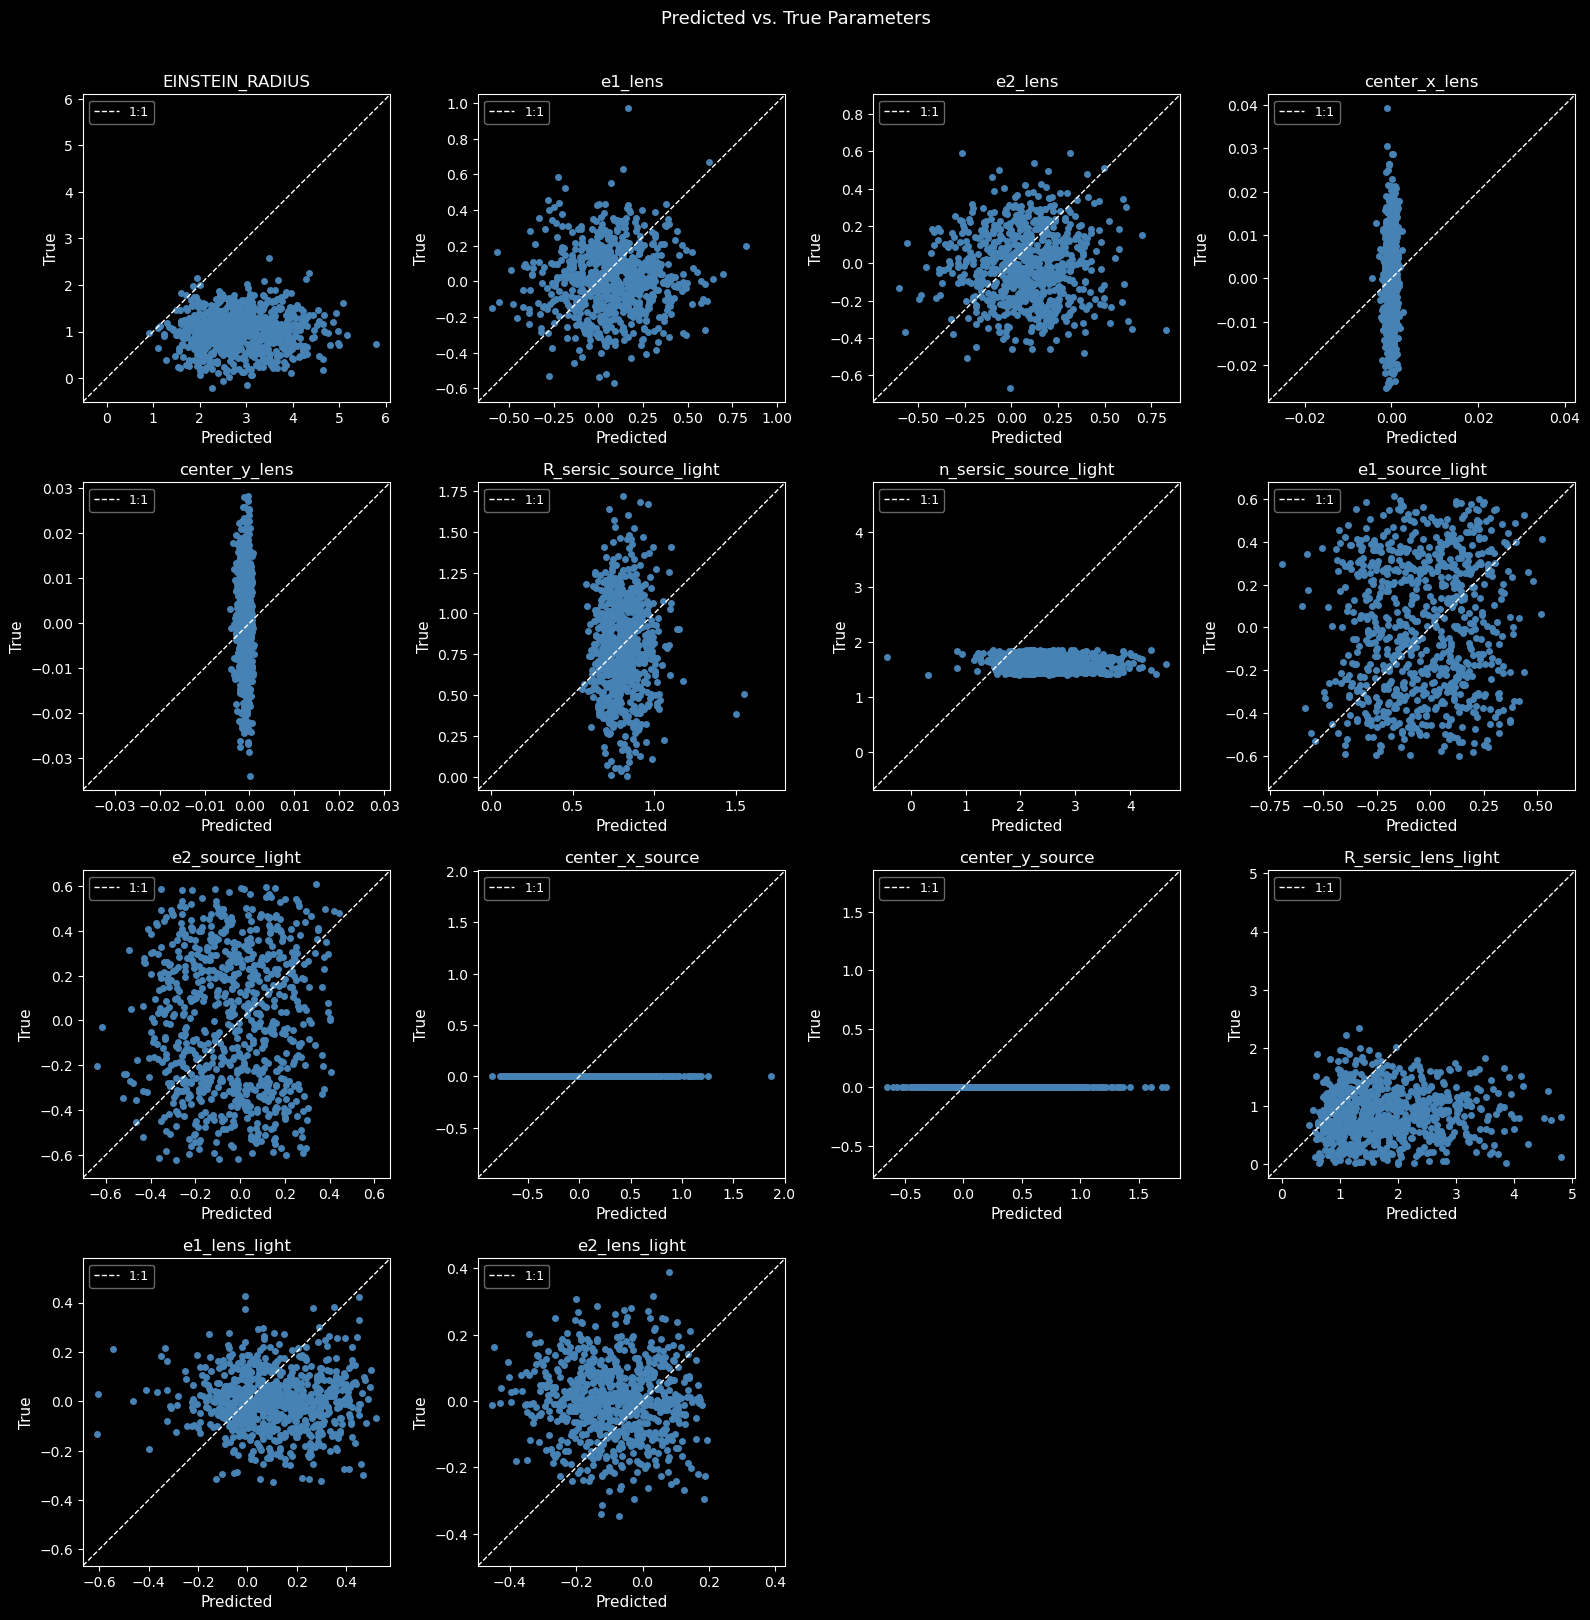

In [16]:
titles = predicted_data.columns.tolist()
n_cols = 4
n_rows = math.ceil(len(titles) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4))
axes = axes.flatten()  # makes indexing easy regardless of shape

for i, (ax, column) in enumerate(zip(axes, titles)):
    ax.plot(predicted_data[column], data[column], 'o', markersize=4, color='steelblue', alpha=1.)
    
    # 1:1 reference line
    all_vals = np.concatenate([predicted_data[column], data[column]])
    lims = [all_vals.min(), all_vals.max()]
    margin = (lims[1] - lims[0]) * 0.05
    lims = [lims[0] - margin, lims[1] + margin]
    ax.plot(lims, lims, 'w--', linewidth=1, alpha=1., label='1:1')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect('equal')
    ax.set_title(column, fontsize=12)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('True', fontsize=11)
    ax.tick_params(labelsize=10)
    ax.legend(fontsize=9, framealpha=0.5)

# Hide any unused axes (14 plots in a 4x4 grid = 2 empty)
for ax in axes[len(titles):]:
    ax.set_visible(False)

plt.suptitle('Predicted vs. True Parameters', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()